# Article Embedding & Classification

## 0. Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

print("All imports loaded.")

All imports loaded.


In [ ]:
import sys
import os

sys.path.append(os.path.abspath(".."))
from src.config import *

np.random.seed(RANDOM_STATE)

plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "font.family": "sans-serif",
        "font.size": 12,
    }
)

plt.style.use("seaborn-v0_8-colorblind")
theme_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

## 1. Data Loading & Preparation

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} rows x {df.shape[1]} columns")
df.head(3)

Loaded 8,606 rows x 15 columns


,Apikey,URL,Title,text,Publish_date,Authors,Section,User_Needs,Views,Avg. views,Engaged minutes,Avg. minutes,Desktop views,Mobile views,Tablet views
0,"pressherald.com, sunjournal.com",http://www.pressherald.com/2026/01/09/gray-inv...,Gray investigated for buying $1.25M fire truck...,Federal and local law enforcement are investig...,2026-01-09 08:55:00,Rory Sweeting,News,update-me,109875,1.084,31960.0,0.315,3910.0,104307.0,1658.0
1,"centralmaine.com, pressherald.com, sunjournal.com",https://www.pressherald.com/2025/03/06/social-...,Social Security now requires Maine parents to ...,"An update, in which the Social Security Admini...",2025-03-06 17:14:00,Joe Lawlor,News,none,98329,1.109,64495.0,0.727,9783.0,86241.0,2305.0
2,"centralmaine.com, pressherald.com, sunjournal.com",http://www.pressherald.com/2026/01/28/ice-agen...,"ICE agents shatter window, leave 1-month-old b...","PORTLAND — Hassane Barry and his wife, Nene, b...",2026-01-28 17:43:00,"Dylan Tusinski,Salomé Cloteaux",News,give-me-perspective,76168,1.145,84939.0,1.277,12634.0,61819.0,1715.0


In [43]:
print(f"Columns: {list(df.columns)}")
print(
    f"Text length - mean: {df['text'].str.len().mean():.0f} chars, median: {df['text'].str.len().median():.0f}, max: {df['text'].str.len().max():.0f}"
)
print(f"\nUser_Needs distribution:")
print(df["User_Needs"].value_counts())

Columns: ['Apikey', 'URL', 'Title', 'text', 'Publish_date', 'Authors', 'Section', 'User_Needs', 'Views', 'Avg. views', 'Engaged minutes', 'Avg. minutes', 'Desktop views', 'Mobile views', 'Tablet views']
Text length - mean: 4242 chars, median: 3878, max: 50597

User_Needs distribution:
User_Needs
none                   4751
update-me              1919
give-me-perspective     727
educate-me              586
connect-me              304
inspire-me              216
help-me                 103
Name: count, dtype: int64


## 2. Text pre-processing

In [4]:
lemmatizer = WordNetLemmatizer()
stop_words_set = set(stopwords.words("english"))
stop_words_set.update(
    {
        "maine",
        "said",
        "one",
        "also",
        "people",
        "state",
        "year",
        "portland",
        "time",
        "like",
        "would",
        "get",
        "new",
    }
)

def clean_text(text: str) -> str:
    """Lowercase, strip HTML/URLs, punctuation, lemmatise."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", "", text) # Remove URLs
    text = re.sub(r"<[^>]+>", "", text) # Remove HTML tags
    text = re.sub(r"[^a-z\s]", " ", text) # Remove punctuation/numbers, keep only letters and spaces
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words_set and len(t) > 2]
    return " ".join(tokens)

def combine_text(row) -> str:
    """Combine title and body text."""
    title_clean = clean_text(row["Title"])
    body_clean = clean_text(row["text"])
    return f"{title_clean} {body_clean}"

def combine_text_short(row, MAX_CHARS: int) -> str:
    """Combine title and first MAX_CHARS chars of body text."""
    title_clean = clean_text(row["Title"])
    body_clean = clean_text(row["text"][:MAX_CHARS])
    return f"{title_clean} {body_clean}"

def combine_text_upweight(row, title_weight: int = 3) -> str:
    """Repeat title to upweight it, then append body text."""
    title_clean = clean_text(row["Title"])
    body_clean = clean_text(row["text"])
    return " ".join([title_clean] * title_weight + [body_clean])

In [6]:
print("Preprocessing all articles...\n")
df["combined_text"] = df.apply(combine_text, axis=1)
df["combined_short"] = df.apply(lambda row: combine_text_short(row, MAX_CHARS=500), axis=1)
df["upweight_combined"] = df.apply(lambda row: combine_text_upweight(row, title_weight=3), axis=1)
df_labeled = df[df["User_Needs"] != "none"].copy()
df_unlabeled = df[df["User_Needs"] == "none"].copy()

print("RESULTS:")
print("=" * 50)
print("Mean character counts:")
print("=" * 50)
print(f"Combined text — mean: {df['combined_text'].str.len().mean():.0f} chars")
print(f"Combined short — mean: {df['combined_short'].str.len().mean():.0f} chars")
print(f"Upweighted combined — mean: {df['upweight_combined'].str.len().mean():.0f} chars\n")

print("=" * 50)
print("Labeled vs Unlabeled Distribution:")
print("=" * 50) 
print(f"Labeled   : {len(df_labeled):,}")
print(f"Unlabeled : {len(df_unlabeled):,}\n")

print("Sample cleaned text:")
print(df["combined_text"].iloc[3][:200])

Preprocessing all articles...

RESULTS:
Mean character counts:
Combined text — mean: 2781 chars
Combined short — mean: 386 chars
Upweighted combined — mean: 2881 chars

Labeled vs Unlabeled Distribution:
Labeled   : 3,855
Unlabeled : 4,751

Sample cleaned text:
mall shooting police search suspect mall fully evacuated south police searching person shot someone inside mall wednesday afternoon first responder brought victim medical center gunshot wound leg inci


In [16]:
df_labeled[["User_Needs", "combined_text", "combined_short", "upweight_combined", "Title", "text"]].to_csv("df_EDA_cleaned.csv", index=False)

## 3. EDA

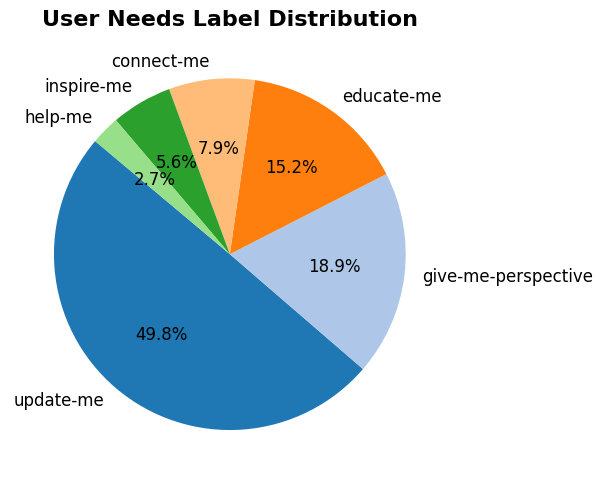


Imbalance ratio (max/min): 18.63x


In [14]:
labeled_counts = df_labeled["User_Needs"].value_counts()

fig, axes = plt.subplots(figsize=(14, 5))
axes.pie(
    labeled_counts.values,
    labels=labeled_counts.index,
    colors=plt.cm.tab20.colors,
    autopct="%1.1f%%",
    startangle=140,
)
axes.set_title("User Needs Label Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

ratio = labeled_counts.max() / labeled_counts.min()
print(f"\nImbalance ratio (max/min): {ratio:.2f}x")

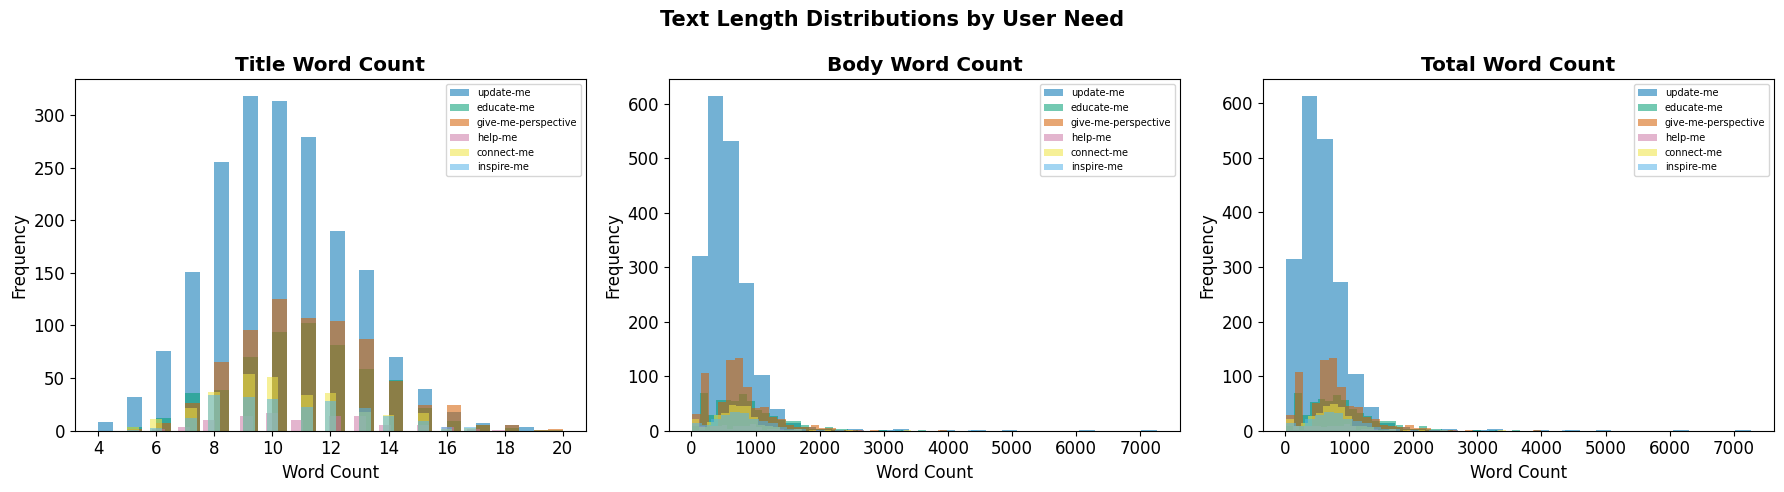

                    title_len                                        text_len  \
                        count  mean  std  min  25%   50%   75%   max    count   
User_Needs                                                                      
connect-me              304.0  10.3  2.5  5.0  9.0  10.0  12.0  17.0    304.0   
educate-me              586.0  10.9  2.5  5.0  9.0  11.0  13.0  20.0    586.0   
give-me-perspective     727.0  11.1  2.4  5.0  9.0  11.0  13.0  20.0    727.0   
help-me                 103.0  11.1  2.7  5.0  9.0  11.0  13.0  18.0    103.0   
inspire-me              216.0  10.7  2.5  5.0  9.0  10.0  12.0  17.0    216.0   
update-me              1919.0  10.0  2.4  4.0  8.0  10.0  12.0  19.0   1919.0   

                                                                       
                      mean    std   min    25%    50%     75%     max  
User_Needs                                                             
connect-me           707.9  391.8  11.0  487.8  694.0 

In [15]:
df_labeled["title_len"] = df_labeled["Title"].str.split().str.len()
df_labeled["text_len"] = df_labeled["text"].str.split().str.len()
df_labeled["total_len"] = df_labeled["title_len"] + df_labeled["text_len"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title in zip(
    axes,
    ["title_len", "text_len", "total_len"],
    ["Title Word Count", "Body Word Count", "Total Word Count"],
):
    for i, label in enumerate(USER_NEEDS_LABELS):
        subset = df_labeled[df_labeled["User_Needs"] == label][col]
        if len(subset):
            ax.hist(subset, bins=30, alpha=0.55, label=label)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Word Count")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=7)

plt.suptitle("Text Length Distributions by User Need", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(df_labeled.groupby("User_Needs")[["title_len", "text_len"]].describe().round(1))

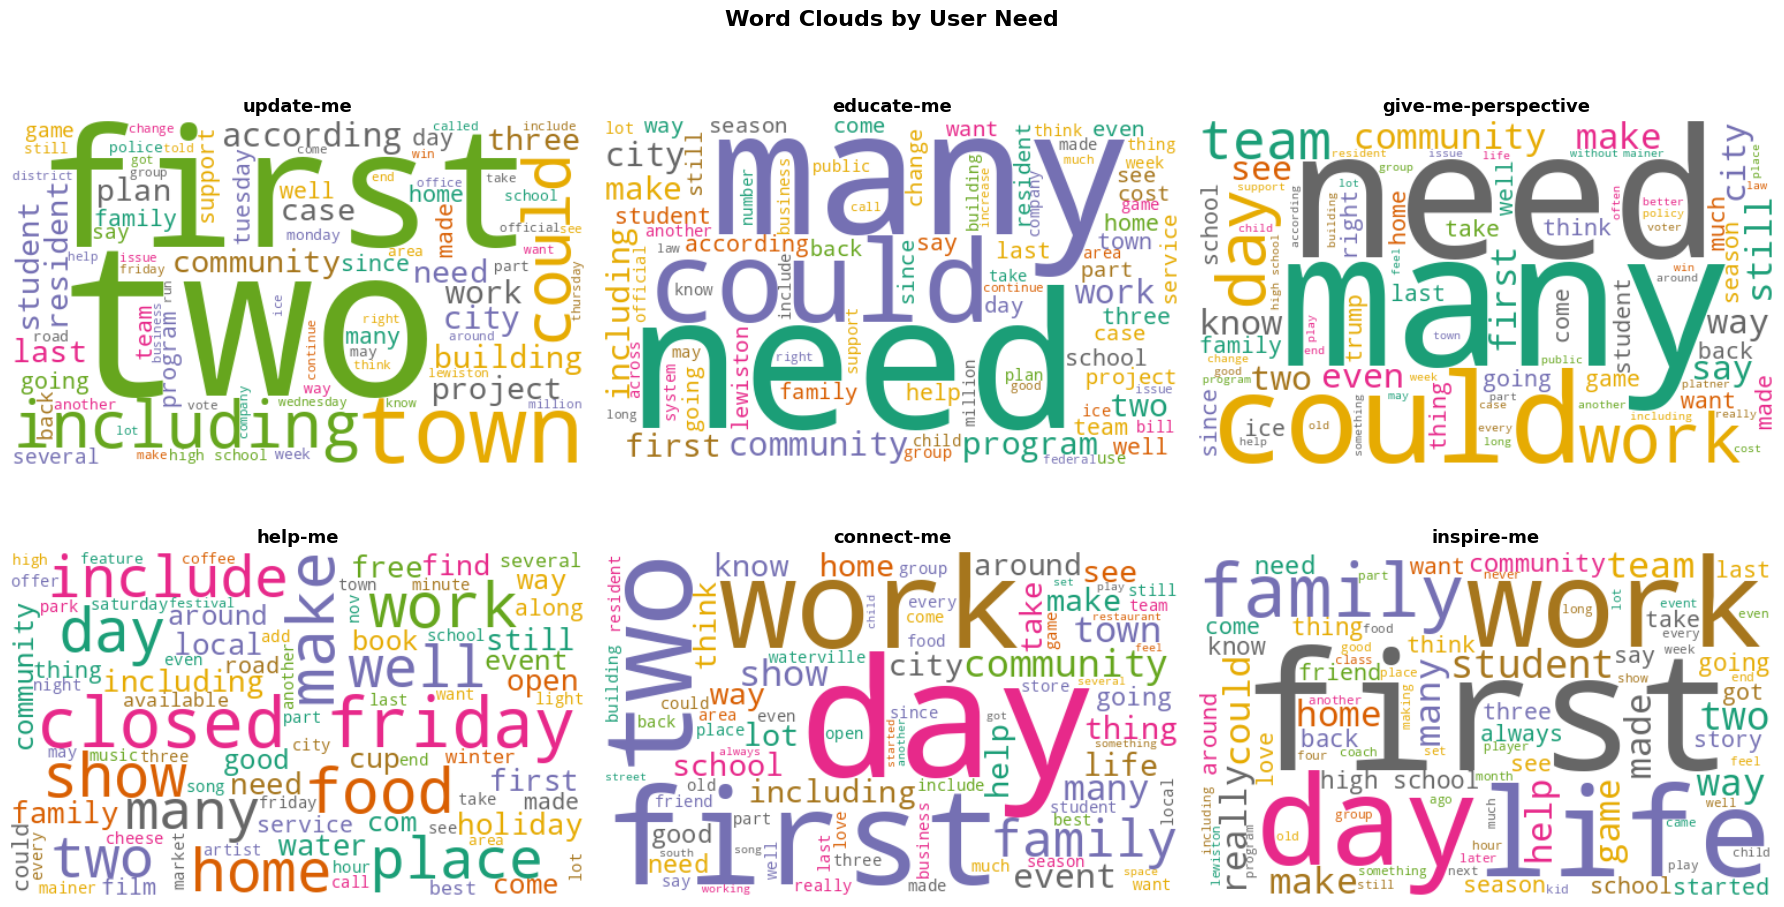

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, label in enumerate(USER_NEEDS_LABELS):
    subset = df[df["User_Needs"] == label]
    text = " ".join(subset["combined_text"].tolist())
    wc = WordCloud(
        width=500,
        height=300,
        stopwords=stop_words_set,
        background_color="white",
        max_words=80,
        colormap=cm.get_cmap("Dark2", 20),
    ).generate(text)
    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(label, fontsize=13, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("Word Clouds by User Need", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()